# XGBoost - 다영 변수조합 실행

`변수조합_설계안_다영.pptx` 기준 조합(+baseline 검증용 조합1b)을 나겸님 XGBoost 코드(`Presentation 5.pdf`)와 동일한 방식(시간순 80:20 분할, scale_pos_weight, subsample/colsample_bytree=0.8, 임계값 스윕)으로 돌린다.

**주의**: 조합1(baseline)에 `category` 원-핫(16개 컬럼)을 넣을지가 성능을 크게 좌우하는 것으로 확인됨(포함 시 PR-AUC 0.89, 제외 시 0.56). `category` 포함 여부를 raw로 볼지는 팀 확인 필요 — 그래서 포함 버전(조합1)과 제외 버전(조합1b)을 둘 다 만들어놨다.

나겸님이 최종 데이터셋을 주면 `DATA_PATH`만 바꿔서 바로 실행하면 된다.

In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

In [12]:
# 나겸님이 만들어주신 최종 데이터셋
DATA_PATH = 'data/fraud_full_features.csv'

df = pd.read_csv(DATA_PATH)
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

# raw category/gender는 XGBoost가 문자열로 못 읽어서 원-핫 인코딩 (조합1 baseline용)
# [버그 수정] "category_"로 시작하는 컬럼만 찾으면 원래 있던 category_recent_fraud_rate,
# category_recent_fraud_rate_missing까지 원-핫 더미로 착각해서 딸려 들어옴 -> get_dummies 전/후 컬럼 차집합으로 진짜 신규 더미만 골라냄
cat_encode_cols = [
    c for c in ['category', 'gender']
    if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])
]
_cols_before = set(df.columns)
if cat_encode_cols:
    df = pd.get_dummies(df, columns=cat_encode_cols, drop_first=False)

CAT_COLS = [c for c in df.columns if c not in _cols_before]
print(df.shape)
print('원-핫으로 새로 생긴 컬럼:', CAT_COLS)
df.head()

(1296675, 44)
원-핫으로 새로 생긴 컬럼: ['category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']


,trans_date_trans_time,cc_num,merchant,amt,is_fraud,recent_24h_high_amt_count,category_recent_fraud_rate,category_recent_fraud_rate_missing,count_30min,Repeat3,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",4.97,0,0,0.0,1,0,0,...,False,False,False,False,True,False,False,False,False,False
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",107.23,0,0,0.0,1,1,0,...,True,False,False,False,False,False,False,False,False,False
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,220.11,0,0,0.0,1,1,0,...,False,False,False,False,False,False,False,False,False,False
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",45.00,0,0,0.0,1,1,0,...,False,False,False,False,False,False,False,False,False,False
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,41.96,0,0,0.0,1,1,0,...,False,False,False,False,False,True,False,False,False,False


In [13]:
# 시간순 80:20 분할 (나겸님 방식과 동일 - 랜덤 분할 아님, 미래 데이터 유출 방지)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f'train: {len(train_df):,}건 (사기 {train_df["is_fraud"].sum():,}건)')
print(f'test : {len(test_df):,}건 (사기 {test_df["is_fraud"].sum():,}건)')

train: 1,037,340건 (사기 5,968건)
test : 259,335건 (사기 1,538건)


In [14]:
# raw(원본) 컬럼만으로 구성한 baseline
# [주의] fraud_full_features.csv에는 lat/long/merch_lat/merch_long/city_pop/dayofweek가 없고
#        hour 대신 trans_hour만 있어서 그만큼 빠진 축소판 baseline임 (거리 관련 raw 신호가 아예 없음)
#        -> 진짜 raw baseline으로 보고 싶으면 나겸님께 저 컬럼들 추가 요청 필요
RAW_BASELINE_FEATURES = [
    'amt', 'age', 'trans_hour',
] + CAT_COLS

FEATURE_COMBOS = {
    '조합1_baseline_raw': RAW_BASELINE_FEATURES,

    # [추가] category 원-핫(16개 컬럼)이 조합1 성능을 사실상 다 만든 것으로 확인돼서,
    # "진짜 raw만" 버전을 따로 분리 - category를 baseline에 넣을지는 팀 확인 필요
    '조합1b_baseline_raw_nocategory': [
        'amt', 'age', 'trans_hour',
    ],

    '조합2_몰아쓰기x속도_binned': [
        'recent_24h_high_amt_count', 'Repeat3', 'high_speed', 'amt',
    ],

    '조합3_이례적소비x업종위험': [
        'amt_zscore_card', 'customer_mean_amt', 'customer_transaction_count',
        'category_recent_fraud_rate', 'category_recent_fraud_rate_missing',
    ],

    '조합4_시간대위험x온라인': [
        'is_online', 'risk_time_22_04', 'recent_24h_high_amt_count', 'amt',
    ],

    '조합5_옵션_압축상호작용': [
        'interact_repeat_category', 'amt', 'is_online', 'customer_transaction_count',
    ],
}

In [15]:
def run_xgb(feature_list, label, thresholds=(0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9)):
    X_train, y_train = train_df[feature_list], train_df['is_fraud']
    X_test, y_test = test_df[feature_list], test_df['is_fraud']

    normal = (y_train == 0).sum()
    fraud = (y_train == 1).sum()
    scale_pos_weight = normal / fraud

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42,
    )
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)

    print(f'\n===== {label} (scale_pos_weight={scale_pos_weight:.2f}) =====')
    print(f'ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')
    print('--- Threshold Test ---')

    rows = []
    for th in thresholds:
        pred = (proba >= th).astype(int)
        p = precision_score(y_test, pred, zero_division=0)
        r = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)
        print(f'Threshold={th:.2f}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')
        rows.append({'threshold': th, 'precision': p, 'recall': r, 'f1': f1})

    return {
        'label': label,
        'model': model,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'threshold_results': pd.DataFrame(rows),
    }

In [16]:
all_results = {}
for name, feats in FEATURE_COMBOS.items():
    missing = [f for f in feats if f not in df.columns]
    if missing:
        print(f'[경고] {name}: 데이터셋에 없는 컬럼 {missing} -> 나겸님 데이터셋 컬럼명 확인 필요, 건너뜀')
        continue
    all_results[name] = run_xgb(feats, name)


===== 조합1_baseline_raw (scale_pos_weight=172.82) =====
ROC-AUC : 0.9984  |  PR-AUC : 0.8951
--- Threshold Test ---
Threshold=0.30  Precision=0.1902  Recall=0.9876  F1=0.3190
Threshold=0.40  Precision=0.2265  Recall=0.9824  F1=0.3681
Threshold=0.50  Precision=0.2652  Recall=0.9792  F1=0.4173
Threshold=0.60  Precision=0.3148  Recall=0.9714  F1=0.4755
Threshold=0.70  Precision=0.3750  Recall=0.9616  F1=0.5396
Threshold=0.80  Precision=0.4299  Recall=0.9493  F1=0.5918
Threshold=0.85  Precision=0.4770  Recall=0.9389  F1=0.6326
Threshold=0.90  Precision=0.5542  Recall=0.9174  F1=0.6910

===== 조합1b_baseline_raw_nocategory (scale_pos_weight=172.82) =====
ROC-AUC : 0.9848  |  PR-AUC : 0.5599
--- Threshold Test ---
Threshold=0.30  Precision=0.0624  Recall=0.9571  F1=0.1171
Threshold=0.40  Precision=0.0773  Recall=0.9402  F1=0.1428
Threshold=0.50  Precision=0.0943  Recall=0.9239  F1=0.1712
Threshold=0.60  Precision=0.1162  Recall=0.9025  F1=0.2059
Threshold=0.70  Precision=0.1466  Recall=0.8784 

In [17]:
# 조합별 요약 비교 (불균형 데이터라 PR-AUC 기준으로 정렬)
summary = pd.DataFrame([
    {'조합': k, 'ROC-AUC': v['roc_auc'], 'PR-AUC': v['pr_auc']}
    for k, v in all_results.items()
]).sort_values('PR-AUC', ascending=False)

print(summary)

# 최적 변수 조합 2개 (PR-AUC 기준 상위 2개) -> 1차 산출물
best_two = summary.head(2)['조합'].tolist()
print('\n최종 채택 후보 2개:', best_two)

                             조합   ROC-AUC    PR-AUC
0              조합1_baseline_raw  0.998412  0.895055
4                 조합4_시간대위험x온라인  0.993345  0.819573
5                 조합5_옵션_압축상호작용  0.984718  0.743988
2            조합2_몰아쓰기x속도_binned  0.986816  0.735678
1  조합1b_baseline_raw_nocategory  0.984827  0.559898
3                조합3_이례적소비x업종위험  0.941507  0.421906

최종 채택 후보 2개: ['조합1_baseline_raw', '조합4_시간대위험x온라인']


## SHAP 해석

각 변수조합 모델이 "왜" 그렇게 예측했는지 뜯어본다. 팀원이 공유한 SHAP 설명 자료 기준 5가지 그래프를 전부 확인한다.

- **Summary Plot**: 이 조합 안에서 어떤 변수가 제일 중요한지, 값이 크면 사기 쪽으로 미는지 정상 쪽으로 미는지
- **Dependence Plot**: 중요도 상위 변수 값이 커질수록/작아질수록 사기 확률이 어떻게 변하는지, 어느 구간에서 영향이 커지는지
- **Force / Waterfall Plot**: 실제로 사기 확률이 가장 높게 나온 거래 1건을 골라서, 어떤 변수가 그 예측을 얼마나 밀어붙였는지
- **Interaction Plot**: 중요도 상위 두 변수를 같이 놓고 시너지 효과가 있는지

시간이 오래 걸릴 수 있어 테스트셋에서 `sample_size`건만 무작위로 뽑아서 계산한다(트리 개수·데이터 크기에 따라 몇 초~몇 분 소요).

In [18]:
def run_shap(result, feature_list, sample_size=2000, top_n_dependence=3, random_state=42):
    model = result['model']
    label = result['label']

    X_test_sample = test_df[feature_list].sample(
        min(sample_size, len(test_df)), random_state=random_state
    )

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test_sample)

    print(f'\n===== SHAP: {label} =====')

    # ① Summary Plot - 전체 변수 중요도 + 영향 방향(빨강=값 큼, 파랑=값 작음)
    shap.summary_plot(shap_values, X_test_sample, show=True)

    # ② Dependence Plot - 중요도 상위 변수들, 값 구간별 영향력 확인
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    top_features = [feature_list[i] for i in np.argsort(mean_abs_shap)[::-1][:top_n_dependence]]
    for feat in top_features:
        shap.dependence_plot(feat, shap_values.values, X_test_sample, show=True)

    # ③ Force Plot - 사기 확률이 가장 높게 나온 거래 1건
    proba_sample = model.predict_proba(X_test_sample)[:, 1]
    fraud_idx = int(np.argmax(proba_sample))
    shap.initjs()
    display(shap.plots.force(shap_values[fraud_idx]))

    # ④ Waterfall Plot - 같은 거래, 변수별 기여도를 계단식으로 확인
    shap.plots.waterfall(shap_values[fraud_idx])

    # ⑤ Interaction Plot - 중요도 1·2위 변수를 같이 놓고 상호작용 확인
    if len(top_features) >= 2:
        shap.dependence_plot(
            top_features[0], shap_values.values, X_test_sample,
            interaction_index=top_features[1], show=True
        )

    return shap_values, X_test_sample


===== SHAP: 조합1_baseline_raw =====


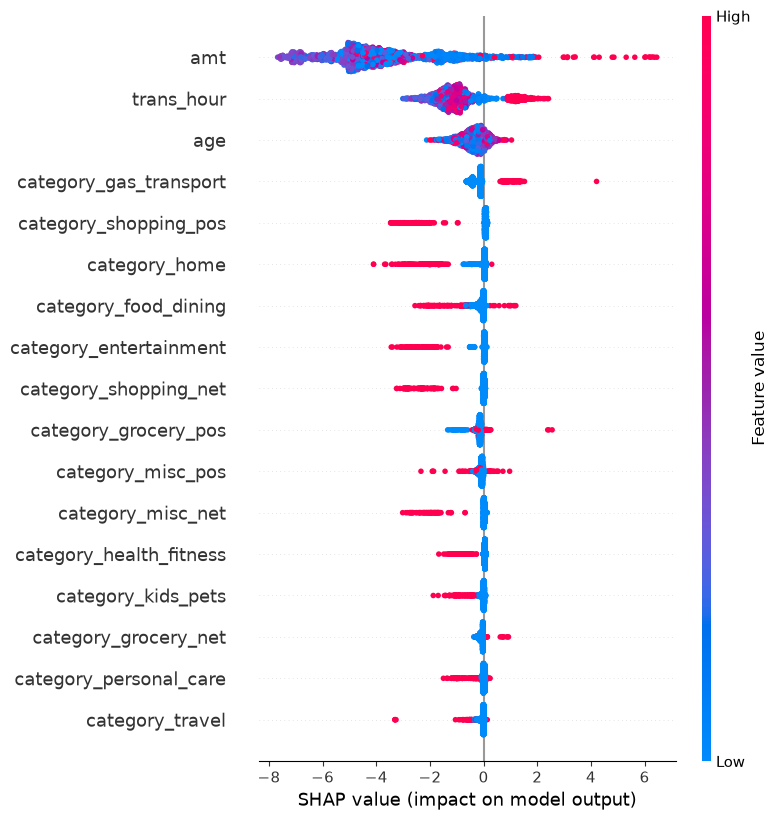

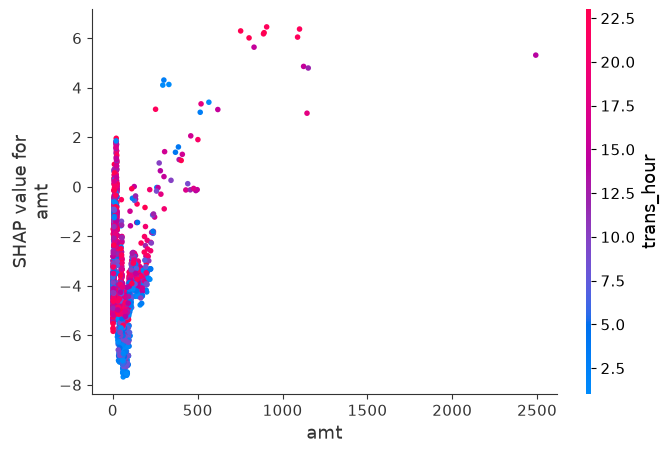

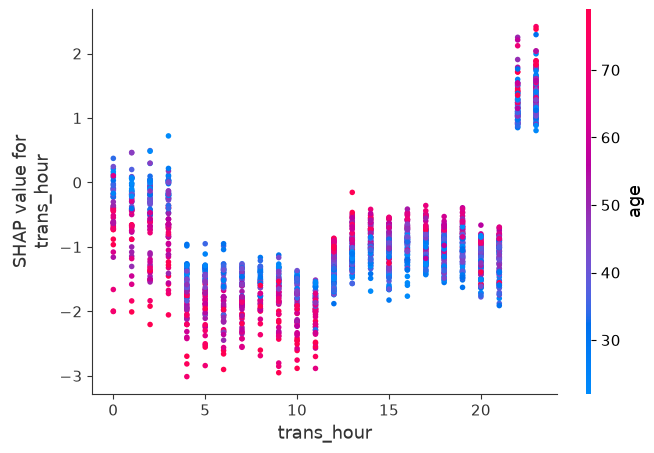

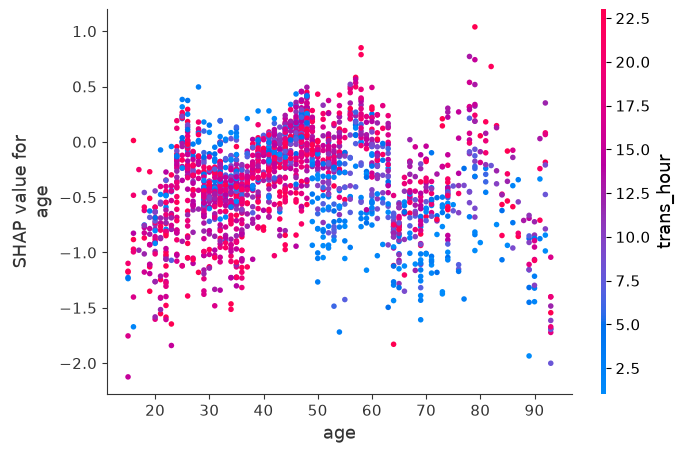

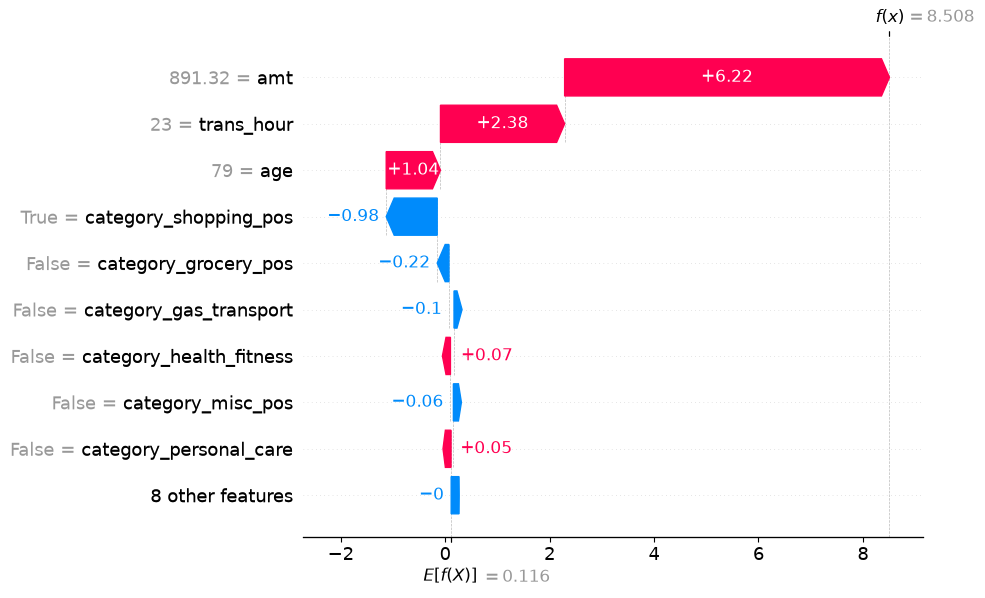

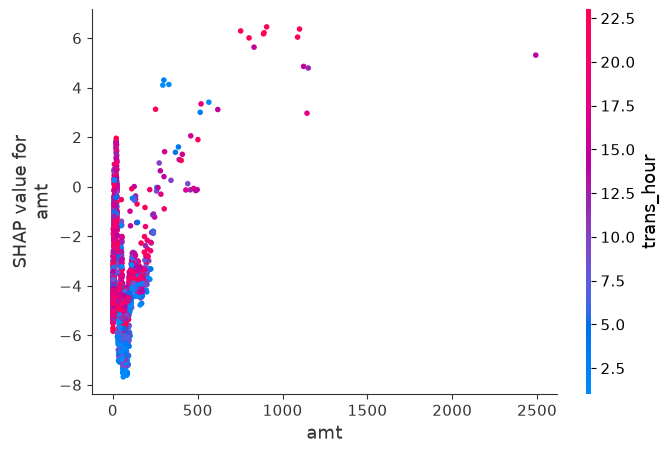


===== SHAP: 조합4_시간대위험x온라인 =====


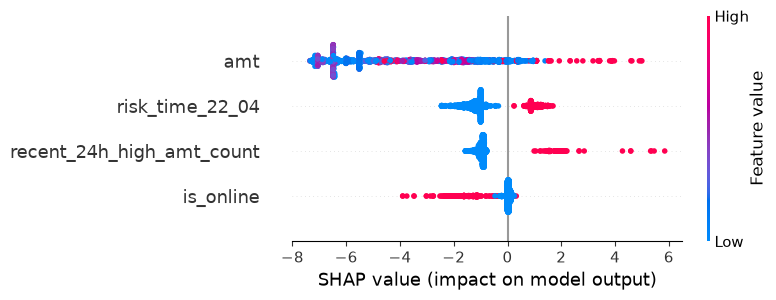

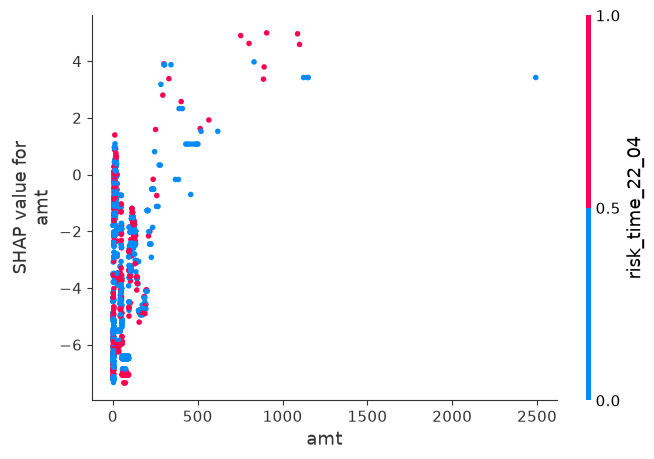

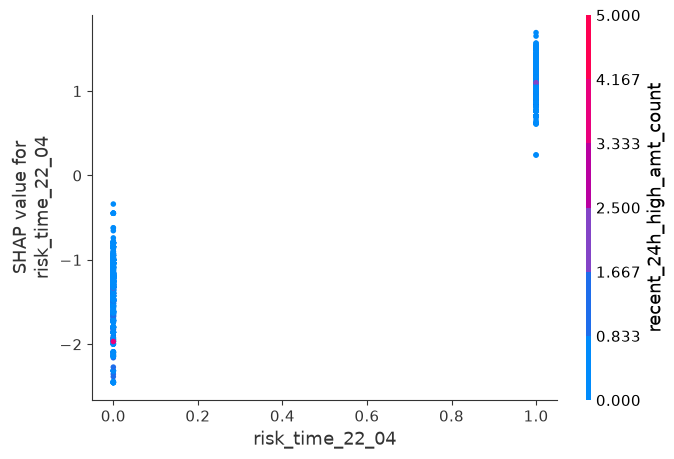

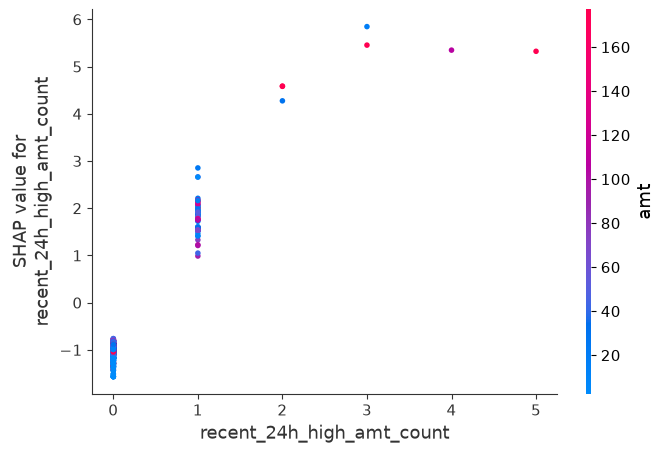

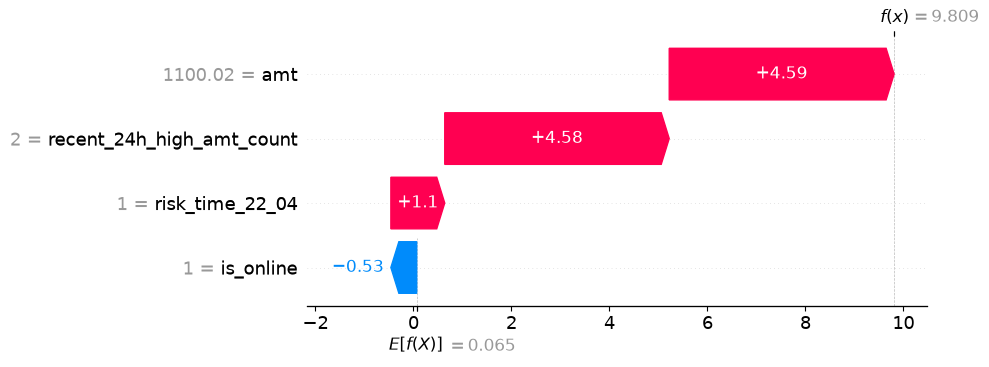

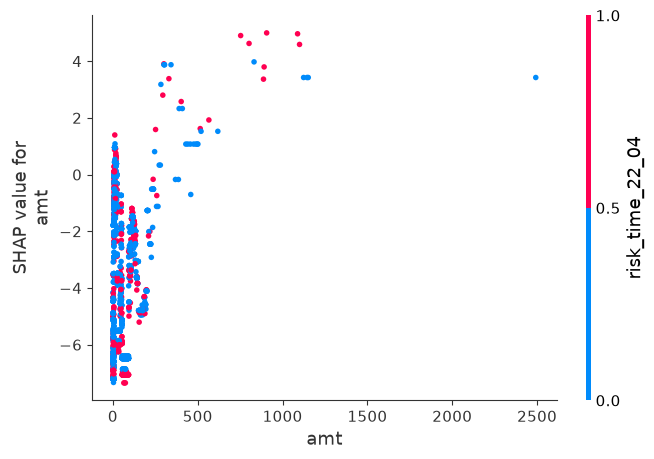

In [19]:
# 조합1, 조합4에 대해서만 SHAP 확인 (전체 조합 다 보고 싶으면 all_results.items()로 변경)
target_combos = ['조합1_baseline_raw', '조합4_시간대위험x온라인']
shap_outputs = {}
for name in target_combos:
    shap_outputs[name] = run_shap(all_results[name], FEATURE_COMBOS[name])

## SHAP으로 확인한 짚어볼 점

트리 300개, 테스트셋 2000건 샘플 기준(조합1·2·3·4·5 전부 확인, `category_recent_fraud_rate`가 조합1에 실수로 섞였던 버그는 수정 완료).

1. **`is_online`이 조합4·조합5에서 방향이 뒤집힘.** 단독 오즈비로는 `is_online`=1이 사기 위험을 높이는 쪽(3.11배)인데, `recent_24h_high_amt_count`·`risk_time_22_04`(또는 `interact_repeat_category`)와 같이 넣으면 SHAP 방향이 반대(↓)로 나옴. 그 강한 변수들이 위험 신호를 이미 대부분 흡수해서, `is_online`에는 "그 위험 신호가 없는 온라인 거래=오히려 평범"이라는 정보만 남는 것으로 해석됨. 단변량 결과와 다변량(SHAP) 결과가 다를 수 있다는 걸 보여주는 사례라 발표 때 언급하기 좋음.

2. **`Repeat3`가 조합2에서 거의 안 쓰임(mean|SHAP|=0.01).** 실제로는 신호가 있음(`Repeat3`=0일 때 사기율 0.57%, 3 이상일 때 2.3~4.7%) — 다만 전체 130만 건 중 0.41%(5,282건)만 3 이상이라 너무 희귀해서, `amt`·`recent_24h_high_amt_count` 같은 강한 변수가 비슷한 케이스를 먼저 잡아버리는 것으로 보임.

3. **`category_recent_fraud_rate_missing`은 조합3에서 사실상 죽은 변수.** 130만 건 중 14건만 1이라(0.001%) 샘플에선 전부 0으로만 나와 SHAP 계산 자체가 안 됨(상관계수 nan). 모델에 해는 없지만 실질적 기여가 없는 변수라, 최종 변수 확정 시 제외 후보로 논의할 만함.


## 사례 연구 — 같은 거래를 조합별로 다르게 판단하는가

조합1(raw)이 가장 심하게 놓친 사기 거래 1건을 골라서, 나머지 조합들은 이 거래를 어떻게 판단하는지 비교한다.

이 방식으로 "왜 변수 조합을 여러 개 만들어서 비교해야 하는가"를 실제 사례로 보여줄 수 있다 — 한 종류의 신호(시간/속도/반복횟수)만으로는 못 잡는 사기를 다른 종류의 신호(고객별 평소 소비 패턴 대비 이탈도)가 잡아내는 경우가 있다.

In [20]:
# 1) 조합1 기준으로 가장 심하게 놓친(확률 낮은) 실제 사기 거래 1건을 찾는다
base_name = '조합1_baseline_raw'
base_model = all_results[base_name]['model']
base_feats = FEATURE_COMBOS[base_name]

proba_base = base_model.predict_proba(test_df[base_feats])[:, 1]
y_test = test_df['is_fraud'].values
fn_mask = (proba_base < 0.1) & (y_test == 1)

fn_positions = np.where(fn_mask)[0]
worst_fn_pos = fn_positions[np.argsort(proba_base[fn_positions])[0]]
target_idx = test_df.index[worst_fn_pos]

# category는 get_dummies로 원본 컬럼이 사라졌으니 원-핫 컬럼 중 1인 것에서 이름 복원
row_cat_cols = [c for c in CAT_COLS if test_df.loc[target_idx, c]]
category_name = row_cat_cols[0].split('_', 1)[1] if row_cat_cols else '(알수없음)'

print(f'{base_name}이 가장 심하게 놓친 사기 거래: idx={target_idx}, 확률={proba_base[worst_fn_pos]:.4f}')
print(test_df.loc[target_idx, ['amt', 'age', 'trans_hour', 'customer_transaction_count', 'is_fraud']])
print('category:', category_name)

# 2) 같은 거래를 6개 조합 전부에 넣어서 확률 비교
case_rows = []
for name, feats in FEATURE_COMBOS.items():
    model = all_results[name]['model']
    proba = model.predict_proba(test_df.loc[[target_idx], feats])[:, 1][0]
    case_rows.append({'조합': name, '예측확률': round(float(proba), 4), '판정': '잡음' if proba >= 0.5 else '놓침'})

case_df = pd.DataFrame(case_rows).sort_values('예측확률', ascending=False)
print()
print(case_df)

조합1_baseline_raw이 가장 심하게 놓친 사기 거래: idx=1114887, 확률=0.0341
amt                           140.03
age                            87.00
trans_hour                     17.00
customer_transaction_count      5.00
is_fraud                        1.00
Name: 1114887, dtype: float64
category: food_dining

                             조합    예측확률  판정
5                 조합5_옵션_압축상호작용  0.9514  잡음
3                조합3_이례적소비x업종위험  0.9382  잡음
2            조합2_몰아쓰기x속도_binned  0.3621  놓침
4                 조합4_시간대위험x온라인  0.0575  놓침
0              조합1_baseline_raw  0.0341  놓침
1  조합1b_baseline_raw_nocategory  0.0057  놓침


--- 조합1_baseline_raw (예측확률=0.0341) ---


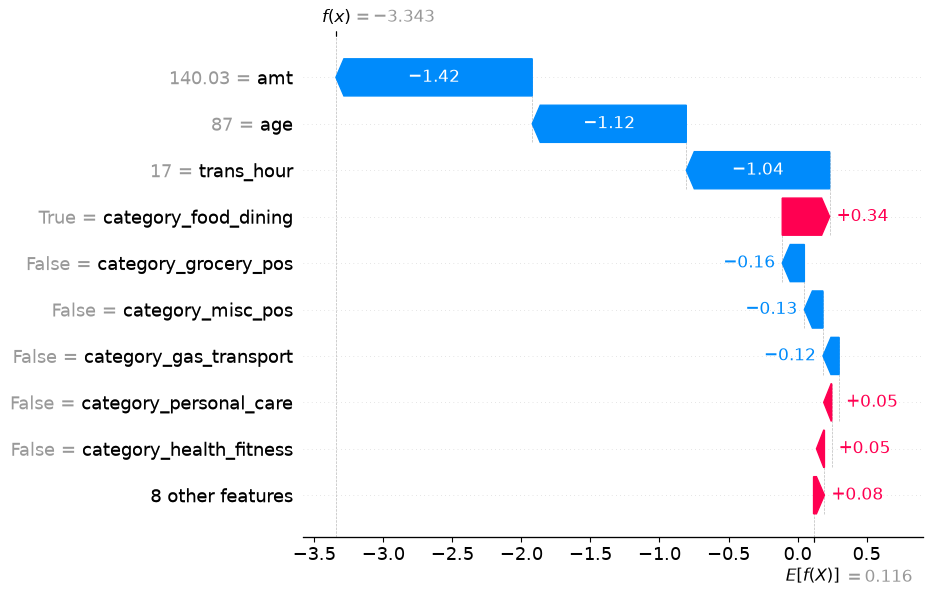

--- 조합1b_baseline_raw_nocategory (예측확률=0.0057) ---


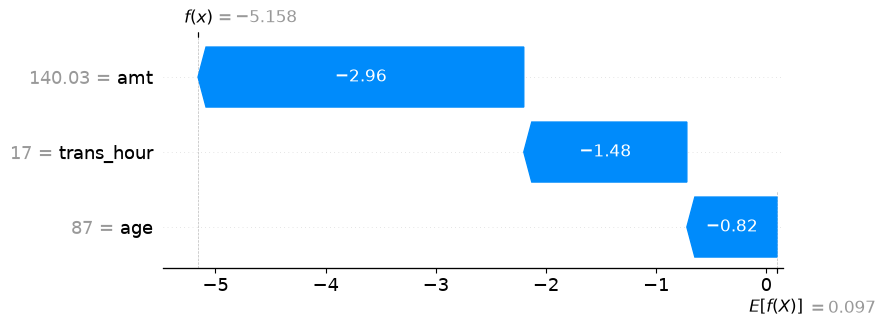

--- 조합2_몰아쓰기x속도_binned (예측확률=0.3621) ---


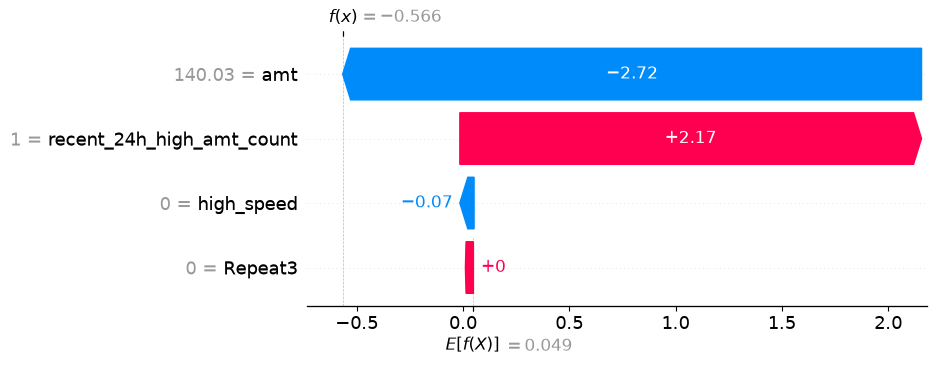

--- 조합3_이례적소비x업종위험 (예측확률=0.9382) ---


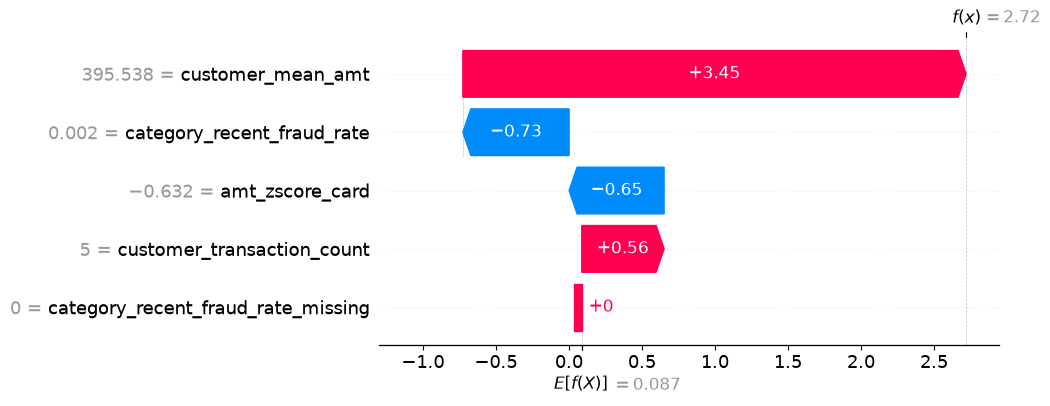

--- 조합4_시간대위험x온라인 (예측확률=0.0575) ---


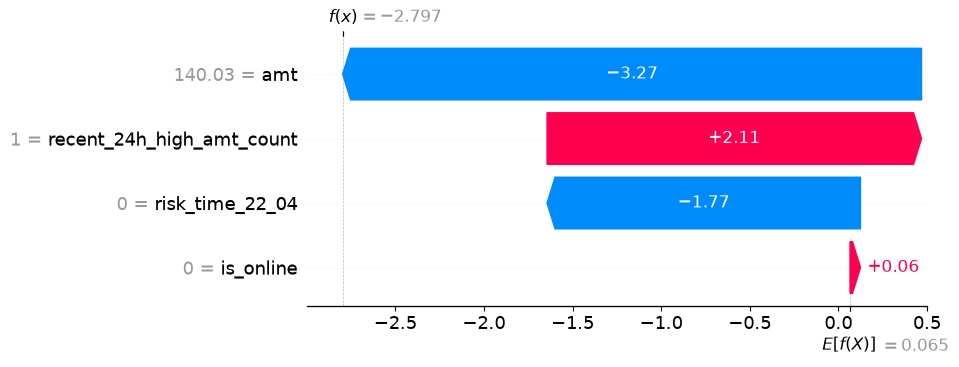

--- 조합5_옵션_압축상호작용 (예측확률=0.9514) ---


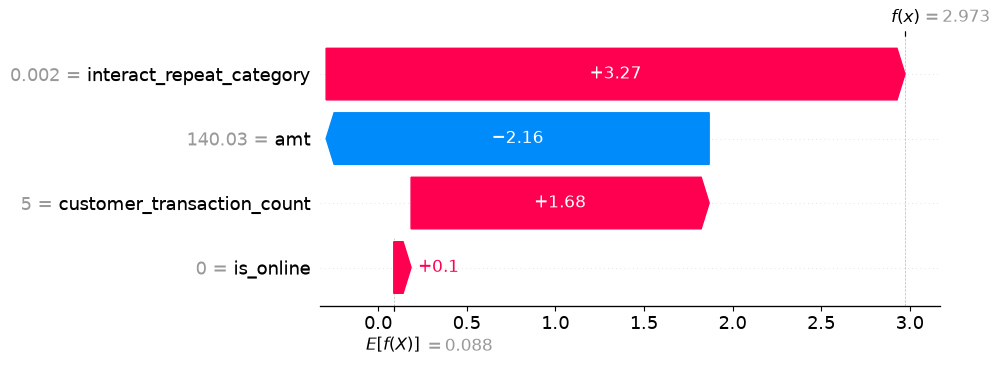

In [21]:
# 3) 조합별로 이 거래에 대한 waterfall plot 확인 (왜 잡았는지 / 왜 놓쳤는지)
for name, feats in FEATURE_COMBOS.items():
    model = all_results[name]['model']
    case = test_df.loc[[target_idx], feats]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(case)

    proba = model.predict_proba(case)[:, 1][0]
    print(f'--- {name} (예측확률={proba:.4f}) ---')
    shap.plots.waterfall(shap_values[0])